In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pypalettes import load_cmap
from pypalettes import get_hex
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import networkx as nx

# 2D NETWORK

In [21]:
import subprocess
import numpy as np
from pathlib import Path

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.87 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.05 # Base standard deviation for aggregation centers (mm)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

filename = fcn.run_2D_tune_positions(parameters2D)

Creating configuration: 2D_initial_configurations/2D_neurons_params_agg_nc10_s0.0500_L3.0_rho250_l0.87_d0.15.txt
Placing nurons randomly in the box...
 Prameters:
L = 3.0
rho = 250
N = 2250
soma_diameter = 0.015
d_mean = 0.150
d_sigma = 0.020
l_mean = 0.870
l_sigma = 0.455
sigma_rayleigh = 0.694
segment_length = 0.010
sigma_axon_angle = 0.100
nc = 10
base_sigma = 0.050














Gini coefficient: 0.8786640277777779


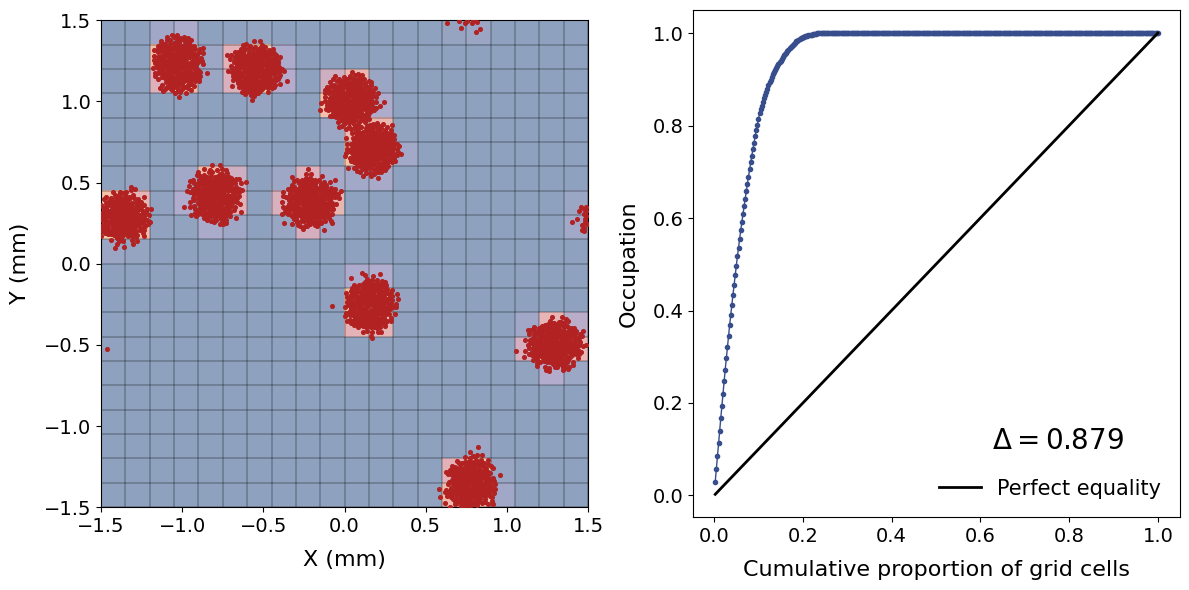

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

fcn.neuron_map_gini2D(filename, parameters2D)

In [23]:
import subprocess
import numpy as np

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "2D_create_network.c",
    "2D_functions.c",
    "-o",
    "2D_create_network.exe",
    "-lm"
])

alphas = [0.2]
# alphas = np.arange(0.0, 1.01, 0.01)

output_filenames = fcn.create_network2D(parameters2D, alphas)

Creating configuration: 2D_created_networks\2D_adjacency_matrix_agg_nc10_s0.0500_L3.0_rho250_l0.87_d0.15_a0.200.txt
['2D_created_networks/2D_adjacency_matrix_agg_nc10_s0.0500_L3.0_rho250_l0.87_d0.15_a0.200.txt']
Parameters loaded from file: 2D_initial_configurations/2D_neurons_params_agg_nc10_s0.0500_L3.0_rho250_l0.87_d0.15.txt
L = 3.0
rho = 250 --> N = 2250
soma_diameter = 0.015
d_mean = 0.150
d_sigma = 0.020
l_mean = 0.870
l_sigma = 0.455
sigma_rayleigh = 0.694
segment_length = 0.010
sigma_axon_angle = 0.100
nc = 10
base_sigma = 0.050
Heades line skipped: X	Y	Soma_Diameter	Dendrite_Diameter	Axon_Length



Trials (intersections) = 841107
Links created          = 168041
Acceptance ratio       = 0.199786




Loading adjacency matrix from: 2D_created_networks/2D_adjacency_matrix_agg_nc10_s0.0500_L3.0_rho250_l0.87_d0.15_a0.200.txt


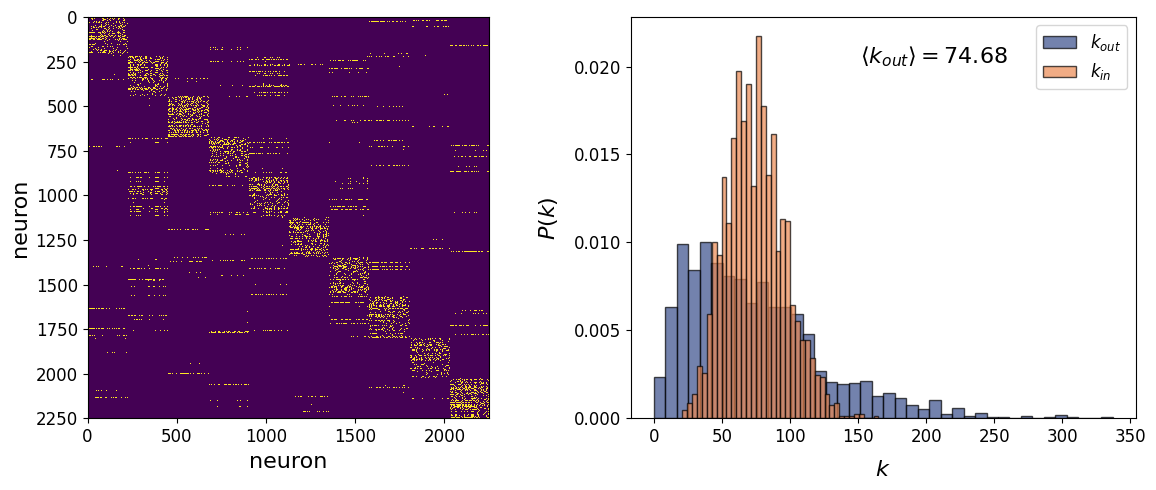

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

filename = output_filenames[0]
print("Loading adjacency matrix from:", filename)

def load_A(path):
    A = np.loadtxt(path, dtype=np.uint8)
    np.fill_diagonal(A, 0)
    return A

A = load_A(filename)

# =========================
# GRADO
# =========================
# Red dirigida: out-degree = suma por filas
k_out = A.sum(axis=1)
k_in = A.sum(axis=0)

# Para histograma discreto
k_vals = np.arange(k_out.max() + 1)
counts = np.bincount(k_out)

# =========================
# FIGURA CON DOS SUBPLOTS
# =========================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --------- MATRIZ DE ADYACENCIA ---------
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest')

ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --------- DISTRIBUCIÓN DE GRADO ---------
k_out_mean = k_out.mean()
# k_in_mean = k_in.mean()
ax = axs[1]

ax.hist(k_out, bins=40, density=True, color=sunset2(0.1), edgecolor='black', alpha=0.7, label = r'$k_{out}$')
ax.hist(k_in, bins=40, density=True, color=sunset2(0.8), edgecolor='black', alpha = 0.7, label = r'$k_{in}$')

# ax.text(0.75, 0.85, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$\n$\\langle k_{{in}} \\rangle = {k_in_mean:.2f}$", fontsize=14, ha='center', va='center', transform=ax.transAxes)

ax.text(0.6, 0.9, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$", fontsize=16, ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel(r'$k$', fontsize=16, labelpad=10)
ax.set_ylabel(r'$P(k)$', fontsize=16, labelpad=10)
ax.legend(fontsize = 12, loc = 'upper right')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [25]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import subprocess
import numpy as np

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 20 # Number of centers for the aggregation of neurons
base_sigma = 0.08 # Base standard deviation for aggregation centers (mm)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

number_of_centers = np.linspace(10, 60, 50, dtype=int)
base_sigmas = np.linspace(0.05, 0.30, 50)
Gini_values2D = []

filenames_Gini = []

for nc in number_of_centers:
    for s in base_sigmas:
        parameters2D["n_centers"] = nc
        parameters2D["base_sigma"] = s

        filename = fcn.run_2D_tune_positions(parameters2D, show_prints=False)
        filenames_Gini.append(filename)

        print(f"Configuration created for n_centers={nc}, base_sigma={s:.4f}", end="\r")

L = parameters2D["L"]
xmin = ymin = -L/2
xmax = ymax = L/2
n_grid = 20

def Gini_coefficient(X, Y, n_grid, xmin, xmax, ymin, ymax):
    H, _, _ = np.histogram2d(X, Y, bins=n_grid, range=[[xmin,xmax],[ymin,ymax]])
    bin_sum = H.sum()

    sum_gini = 0.0
    H_flat = H.flatten()
    H_flat.sort()
    H_flat = H_flat[::-1]

    G = np.zeros(len(H_flat))

    for i, h in enumerate(H_flat):
        sum_gini += h
        G[i] = sum_gini/bin_sum

    bins = np.arange(1, len(H_flat)+1)
    bins = bins/len(H_flat)

    area_between = np.trapezoid(G-bins, bins)
    Gini = 2*area_between
    return Gini

for filename in filenames_Gini:
    X, Y, _, _, _ = fcn.load_neuron_params(filename)
    Gini = Gini_coefficient(X, Y, n_grid, xmin, xmax, ymin, ymax)
    Gini_values2D.append(Gini)

KeyboardInterrupt: 

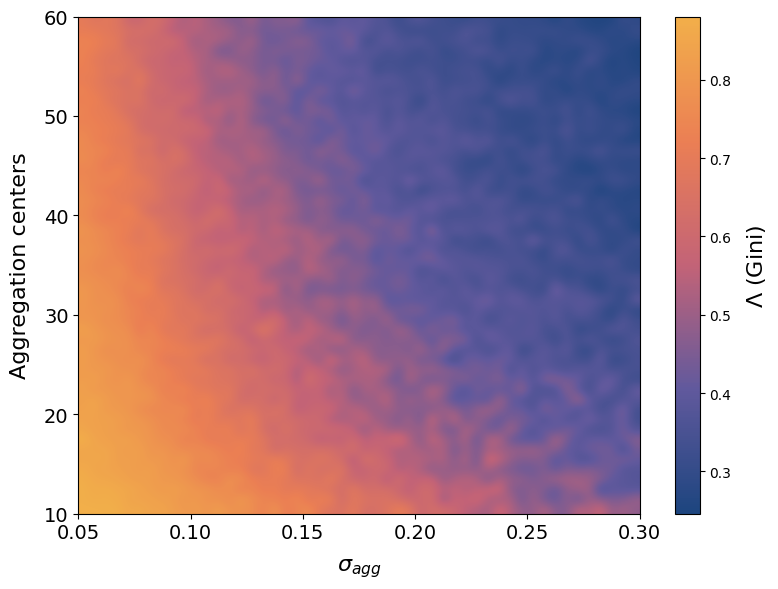

In [4]:
from pypalettes import load_cmap
import matplotlib.pyplot as plt

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

Gini_map = np.array(Gini_values2D).reshape(len(number_of_centers), len(base_sigmas))

plt.figure(figsize=(8,6))

im = plt.imshow(
    Gini_map,
    origin='lower',
    aspect='auto',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    interpolation='bicubic'
)

plt.xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad = 10)
plt.ylabel(r'Aggregation centers', fontsize=16, labelpad  = 10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

cbar = plt.colorbar(im)
cbar.set_label(r'$\Lambda$' + ' (Gini)', fontsize=16, labelpad = 10)

plt.tight_layout()
plt.show()

# -- 2D DYNAMICS --

Creating configuration: 2D_initial_configurations/2D_neurons_params_agg_nc15_s0.2850_L3.0_rho250_l0.50_d0.15.txt
Placing nurons randomly in the box...
 Prameters:
L = 3.0
rho = 250
N = 2250
soma_diameter = 0.015
d_mean = 0.150
d_sigma = 0.020
l_mean = 0.500
l_sigma = 0.261
sigma_rayleigh = 0.399
segment_length = 0.010
sigma_axon_angle = 0.100
nc = 15
base_sigma = 0.285

















Configuration already exists: 2D_created_networks\2D_adjacency_matrix_agg_nc15_s0.2850_L3.0_rho250_l0.50_d0.15_a0.200.txt
Shape: (2250, 2250)
k =  24.228444444444445


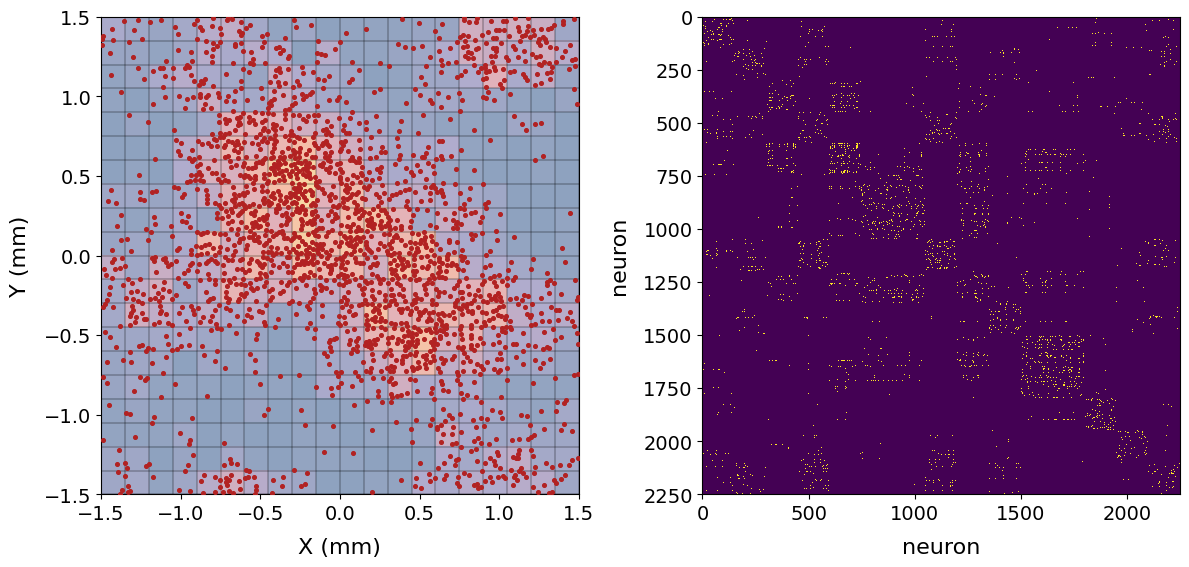

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# -------- PARAMETERS --------

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 15 # Number of centers for the aggregation of neurons
base_sigma = 0.2850 # Base standard deviation for aggregation centers (mm)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

alphas = [0.2]
# alphas = np.arange(0.0, 1.01, 0.01)

filename_params = fcn.run_2D_tune_positions(parameters2D)
path = fcn.create_network2D(parameters2D, alphas)[0]

# -------- USO --------

A = fcn.load_A(path)
C, k, E = fcn.connectivity_from_A(A)

print("Shape:", A.shape)
print('k = ', k)

# Visualización
fcn.neuron_map_adj2D(filename_params, path, parameters2D)

# -------- Pesos --------

N = A.shape[0]

Ne = int(N*0.8)
Ni = int(N*0.2)
N = Ne + Ni

SIM_TIME = 5000

# 2) Izhikevich parameters (con variabilidad)
re = np.random.rand(Ne, 1)
ri = np.random.rand(Ni, 1)

a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

MAX_EXC_WEIGTH = 8
MAX_INH_WEIGTH = 0.5

W = np.hstack([
    MAX_EXC_WEIGTH*np.random.rand(N, Ne),
    -MAX_INH_WEIGTH*np.random.rand(N, Ni)
])

S = A * W
NOISE_MAX = 3

In [18]:
v = -65*np.ones((N, 1))
u = b * v

firings_t = [] # tiempos de disparo
firings_i = [] # índices de neuronas que disparan (0..N-1)

for t in range(1, SIM_TIME+1):
    I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

    fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

    if fired.size > 0:
        firings_t.append(np.full(fired.shape, t, dtype=int))
        firings_i.append(fired.copy())

        v[fired] = c[fired]
        u[fired] = u[fired] + d[fired]

        # I = I + sum(S(:, fired), 2)
        # En numpy: sumamos columnas "fired" y nos queda vector Nx1
        I = I + np.sum(S[:, fired], axis=1, keepdims=True)

    # Integración (paso 0.5 ms x2)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    u = u + a*(b*v - u)

# Convertir lista de arrays a arrays.
#  planos
if len(firings_t) > 0:
    firings_t = np.concatenate(firings_t)
    firings_i = np.concatenate(firings_i) + 1  # +1 si quieres neuronas 1..N como en MATLAB
else:
    firings_t = np.array([], dtype=int)
    firings_i = np.array([], dtype=int)

print("Total spikes:", len(firings_t))

Total spikes: 43590


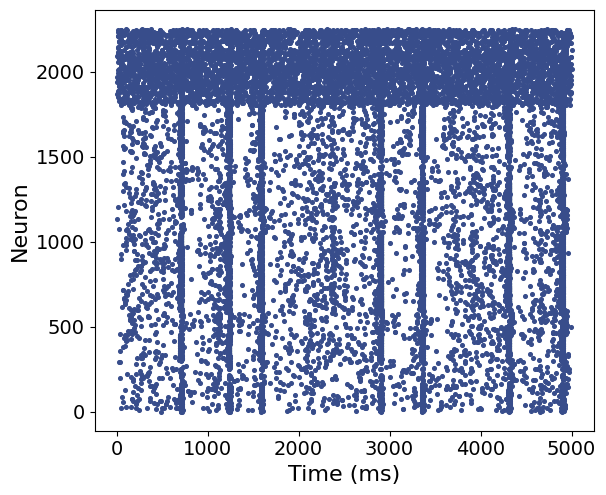

In [19]:
from pypalettes import load_cmap
import matplotlib.pyplot as plt

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

plt.figure(figsize=(6, 5))
plt.scatter(firings_t, firings_i, s=7, color=sunset2(0.1))
plt.xlabel('Time (ms)', fontsize=16)
plt.ylabel('Neuron', fontsize=16)
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim(200, 300)
plt.show()

Número de picos detectados: 7
Alturas de los picos (%): [0.52266667 0.53377778 0.52088889 0.50977778 0.504      0.52488889
 0.52666667]
Altura media de los picos (%): 0.5203809523809524


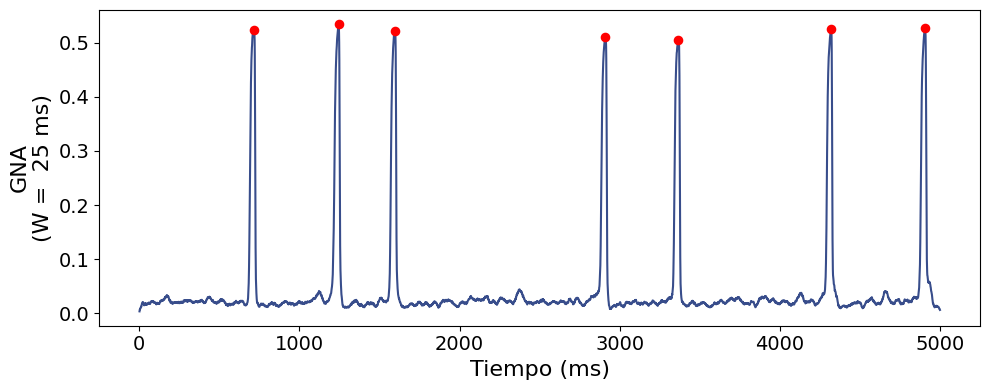

In [20]:
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks

W = 25  # ms

GNA, active_neurons_count = fcn.compute_GNA_from_raster(
    firings_t=firings_t,
    firings_i=firings_i,
    N=N,
    SIM_TIME=SIM_TIME,
    W=W,
    indices_are_1_based=True   # en tu código hiciste +1 al final
)

peaks, properties = find_peaks(
    GNA,
    height=0.1,      # altura mínima del pico en %
    distance=20    # separación mínima entre picos (ms)
)

peak_heights = properties["peak_heights"]
mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0

print("Número de picos detectados:", len(peaks))
print("Alturas de los picos (%):", peak_heights)
print("Altura media de los picos (%):", mean_peak_height)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, SIM_TIME + 1), GNA, lw=1.5, color=sunset2(0.1))
plt.scatter(peaks + 1, GNA[peaks], s=35, color="red", zorder=3)

plt.xlabel("Tiempo (ms)", fontsize=16)
plt.ylabel(f"GNA\n(W =  {W} ms)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.xlim(0, 2000)
plt.show()

## -- 2D GNA map --

In [4]:
import subprocess
import numpy as np
import os

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

number_of_centers = 15
base_sigmas = np.linspace(0.05, 0.30, 50)

# Handle both a single int and an iterable of centers
n_centers_iter = np.atleast_1d(number_of_centers).astype(int)


for base_sigma in base_sigmas:
    for nc in n_centers_iter:
        parameters2D["n_centers"] = nc
        parameters2D["base_sigma"] = base_sigma

        filename = fcn.run_2D_tune_positions(parameters2D, show_prints=False)
        print(f"Configuration created for n_centers={nc}, base_sigma={base_sigma:.4f}", end="\r")

filenames_params = [
    f"2D_initial_configurations/2D_neurons_params_agg_nc{nc}_s{s:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}.txt"
    for nc in n_centers_iter
    for s in base_sigmas
]
#Check if files exist
for filename in filenames_params:
    if not os.path.isfile(filename):
        print(f"File not found: {filename}")

In [6]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_create_network.c",
    "2D_functions.c",
    "-o",
    "2D_create_network.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

number_of_centers = 15
parameters2D["n_centers"] = number_of_centers
base_sigmas = np.linspace(0.05, 0.30, 50)   
print('Length of base_sigmas:', len(base_sigmas))
print(base_sigmas)

alphas = [0.2]

for base_sigma in base_sigmas:
    parameters2D["base_sigma"] = base_sigma
    filename = fcn.create_network2D(parameters2D, alphas, show_prints=False)[0]
    print(filename)
    print(f"Created network for n_centers={number_of_centers}, {parameters2D['base_sigma']:.4f}", end="\r")

Length of base_sigmas: 50
[0.05       0.05510204 0.06020408 0.06530612 0.07040816 0.0755102
 0.08061224 0.08571429 0.09081633 0.09591837 0.10102041 0.10612245
 0.11122449 0.11632653 0.12142857 0.12653061 0.13163265 0.13673469
 0.14183673 0.14693878 0.15204082 0.15714286 0.1622449  0.16734694
 0.17244898 0.17755102 0.18265306 0.1877551  0.19285714 0.19795918
 0.20306122 0.20816327 0.21326531 0.21836735 0.22346939 0.22857143
 0.23367347 0.23877551 0.24387755 0.24897959 0.25408163 0.25918367
 0.26428571 0.26938776 0.2744898  0.27959184 0.28469388 0.28979592
 0.29489796 0.3       ]
2D_created_networks/2D_adjacency_matrix_agg_nc15_s0.0500_L3.0_rho250_l0.50_d0.15_a0.200.txt
2D_created_networks/2D_adjacency_matrix_agg_nc15_s0.0551_L3.0_rho250_l0.50_d0.15_a0.200.txt
2D_created_networks/2D_adjacency_matrix_agg_nc15_s0.0602_L3.0_rho250_l0.50_d0.15_a0.200.txt
2D_created_networks/2D_adjacency_matrix_agg_nc15_s0.0653_L3.0_rho250_l0.50_d0.15_a0.200.txt
2D_created_networks/2D_adjacency_matrix_agg_nc1

In [ ]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

nc = 15
parameters2D["n_centers"] = nc
base_sigmas = np.linspace(0.05, 0.30, 50)   
print('Length of base_sigmas:', len(base_sigmas))

MAX_EXC_WEIGTH = np.linspace(2, 6, len(base_sigmas))  # Puedes ajustar esto según tus necesidades
print('Length of MAX_EXC_WEIGTH:', len(MAX_EXC_WEIGTH))
MAX_INH_WEIGTH = 0.5

alpha = 0.2

output_filename = f'maps_results/2D_colormap_Gini_Exc_GNA_nc{nc}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}_a{alpha:.3f}.txt'
with open(output_filename, 'w') as f:
     f.write("Gini\tMAX_EXC_WEIGTH\tmean_peaks_height\tstd_peaks_height\n")

i = 0
for base_sigma in base_sigmas:
    parameters2D["base_sigma"] = base_sigma
    path_params = f"2D_initial_configurations/2D_neurons_params_agg_nc{parameters2D['n_centers']}_s{parameters2D['base_sigma']:.4f}_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}.txt"
    X, Y, _, _, _ = fcn.load_neuron_params(path_params)
    Gini = fcn.Gini_coefficient(X, Y, n_grid = 20, xmin = -parameters2D['L']/2, xmax = parameters2D['L']/2, ymin = -parameters2D['L']/2, ymax = parameters2D['L']/2)
    path_adj = f"2D_created_networks/2D_adjacency_matrix_agg_nc{parameters2D['n_centers']}_s{parameters2D['base_sigma']:.4f}_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}_a{alpha:.3f}.txt"
    A = fcn.load_A(path_adj)
    N = A.shape[0]

    Ne = int(N*0.8)
    Ni = int(N*0.2)
    N = Ne + Ni

    SIM_TIME = 5000

    # 2) Izhikevich parameters (con variabilidad)
    re = np.random.rand(Ne, 1)
    ri = np.random.rand(Ni, 1)

    a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
    b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
    c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
    d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

    for max_exc in MAX_EXC_WEIGTH:

        W = np.hstack([
            max_exc*np.random.rand(N, Ne),
            -MAX_INH_WEIGTH*np.random.rand(N, Ni)
        ])

        S = A * W
        NOISE_MAX = 3

        v = -65*np.ones((N, 1))
        u = b * v

        firings_t = [] # tiempos de disparo
        firings_i = [] # índices de neuronas que disparan (0..N-1)

        for t in range(1, SIM_TIME+1):
            I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

            fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

            if fired.size > 0:
                firings_t.append(np.full(fired.shape, t, dtype=int))
                firings_i.append(fired.copy())

                v[fired] = c[fired]
                u[fired] = u[fired] + d[fired]

                # I = I + sum(S(:, fired), 2)
                # En numpy: sumamos columnas "fired" y nos queda vector Nx1
                I = I + np.sum(S[:, fired], axis=1, keepdims=True)

            # Integración (paso 0.5 ms x2)
            v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
            v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
            u = u + a*(b*v - u)

        # Convertir lista de arrays a arrays.
        #  planos
        if len(firings_t) > 0:
            firings_t = np.concatenate(firings_t)
            firings_i = np.concatenate(firings_i) + 1  # +1 si quieres neuronas 1..N como en MATLAB
        else:
            firings_t = np.array([], dtype=int)
            firings_i = np.array([], dtype=int)
        
        print(f"Simulated network for base_sigma={base_sigma:.4f}, max_exc={max_exc:.2f}, Gini={Gini:.4f}, total spikes={len(firings_t)}")

        GNA, active_neurons_count = fcn.compute_GNA_from_raster(
            firings_t=firings_t,
            firings_i=firings_i,
            N=N,
            SIM_TIME=SIM_TIME,
            W=25,
            indices_are_1_based=True
        )
        peaks, properties = find_peaks(
            GNA,
            height=0.1,      # altura mínima del pico en %
            distance=20    # separación mínima entre picos (ms)
        )
        peak_heights = properties["peak_heights"]
        mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0
        print(f"Detected {len(peaks)} peaks in GNA for base_sigma={base_sigma:.4f}, max_exc={max_exc:.2f}, mean_peak_height={mean_peak_height:.4f}%")
        std_peak_height = np.std(peak_heights) if len(peak_heights) > 0 else 0.0

        with open(output_filename, 'a') as f:
            f.write(f"{Gini}\t{max_exc}\t{mean_peak_height}\t{std_peak_height}\n")
        
    i += 1

Length of base_sigmas: 50
Length of MAX_EXC_WEIGTH: 50
Simulated network for base_sigma=0.0500, max_exc=2.00, Gini=0.8662, total spikes=7293
Simulated network for base_sigma=0.0500, max_exc=2.08, Gini=0.8662, total spikes=7347
Simulated network for base_sigma=0.0500, max_exc=2.16, Gini=0.8662, total spikes=7323
Simulated network for base_sigma=0.0500, max_exc=2.24, Gini=0.8662, total spikes=7375
Simulated network for base_sigma=0.0500, max_exc=2.33, Gini=0.8662, total spikes=7448
Simulated network for base_sigma=0.0500, max_exc=2.41, Gini=0.8662, total spikes=7403
Simulated network for base_sigma=0.0500, max_exc=2.49, Gini=0.8662, total spikes=7396
Simulated network for base_sigma=0.0500, max_exc=2.57, Gini=0.8662, total spikes=7348
Simulated network for base_sigma=0.0500, max_exc=2.65, Gini=0.8662, total spikes=7409
Simulated network for base_sigma=0.0500, max_exc=2.73, Gini=0.8662, total spikes=7378
Simulated network for base_sigma=0.0500, max_exc=2.82, Gini=0.8662, total spikes=7416

Index(['Gini', 'MAX_EXC_WEIGTH', 'mean_peaks_height', 'std_peaks_height'], dtype='object')


C:\Users\Admin\AppData\Local\Temp\ipykernel_444\1639565598.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("maps_results/2D_colormap_Gini_Exc_GNA_nc15_L3.0_rho250_l0.50_d0.15_a0.200.txt", delim_whitespace=True)


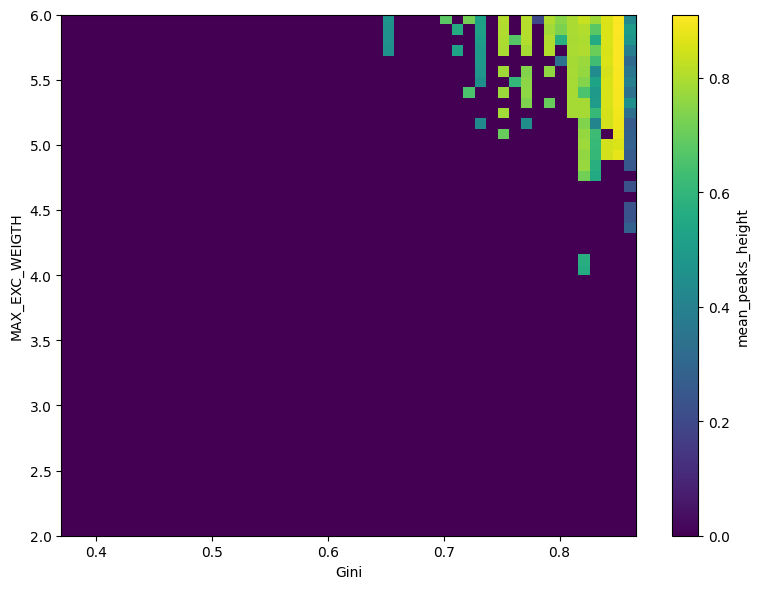

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el txt
df = pd.read_csv("maps_results/2D_colormap_Gini_Exc_GNA_nc15_L3.0_rho250_l0.50_d0.15_a0.200.txt", delim_whitespace=True)

# Por si acaso, revisa nombres de columnas
print(df.columns)

# Crear tabla tipo matriz
heatmap_data = df.pivot(
    index="MAX_EXC_WEIGTH",
    columns="Gini",
    values="mean_peaks_height"
)

# Dibujar mapa de calor
plt.figure(figsize=(8, 6))
im = plt.imshow(
    heatmap_data,
    origin="lower",
    aspect="auto",
    extent=[
        heatmap_data.columns.min(),
        heatmap_data.columns.max(),
        heatmap_data.index.min(),
        heatmap_data.index.max()
    ]
)

plt.xlabel("Gini")
plt.ylabel("MAX_EXC_WEIGTH")
cbar = plt.colorbar(im)
cbar.set_label("mean_peaks_height")

plt.tight_layout()
plt.show()

# 3D NETWORK

In [26]:
import subprocess
import numpy as np
from pathlib import Path
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.5 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.47 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 0 # Control parameter for the aggregation of neurons
n_centers = 25 # Number of centers for the aggregation of neurons
base_sigma = 0.05 # Base standard deviation for aggregation centers (mm)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

filename = fcn.run_3D_tune_positions(parameters3D)

Creating configuration: 3D_initial_configurations/3D_neurons_params_random_L3.0_rho250_l0.47_d0.50.txt
Placing neurons randomly in the box...
Parameters:
L = 3.0
rho = 250
N = 6750
soma_diameter = 0.015
d_mean = 0.500
d_sigma = 0.020
l_mean = 0.470
l_sigma = 0.246
sigma_rayleigh = 0.375
segment_length = 0.010
sigma_pol = 0.100
sigma_azi = 0.100





In [111]:
%matplotlib inline

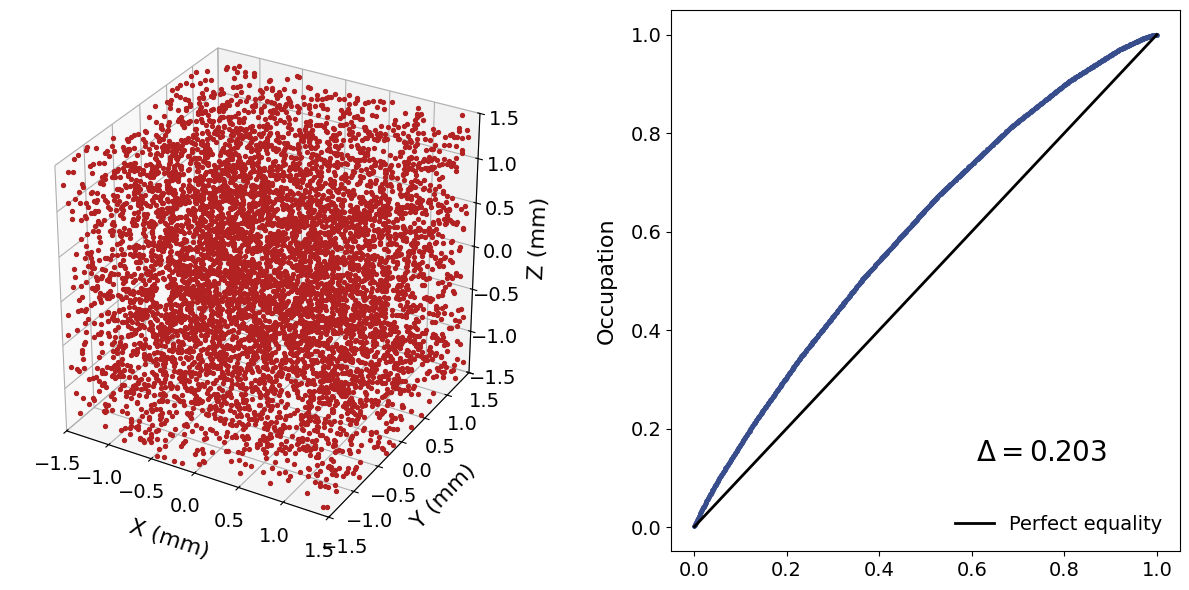

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

fcn.neuron_map_gini3D(filename, parameters3D)

In [28]:
import subprocess
import numpy as np

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_create_network.c",
    "3D_functions.c",
    "-o",
    "3D_create_network.exe",
    "-lm"
])

alphas = [0.2]
# alphas = np.arange(0.0, 1.01, 0.01)

output_filenames = fcn.create_network3D(parameters3D, alphas)

Creating configuration: 3D_created_networks\3D_adjacency_matrix_random_L3.0_rho250_l0.47_d0.50_a0.200.txt
Parameters loaded from file: 3D_initial_configurations/3D_neurons_params_random_L3.0_rho250_l0.47_d0.50.txt
L = 3.0
rho = 250 --> N = 6750
soma_diameter = 0.015
d_mean = 0.500
d_sigma = 0.020
l_mean = 0.470
l_sigma = 0.246
sigma_rayleigh = 0.375
segment_length = 0.010
sigma_pol = 0.100
sigma_azi = 0.100
nc = 0
base_sigma = 0.0000
Header line skipped: X	Y	Z	Soma_Diameter	Dendrite_Diameter	Axon_Length



Trials (intersections) = 1188237
Links created          = 237288
Acceptance ratio       = 0.199698




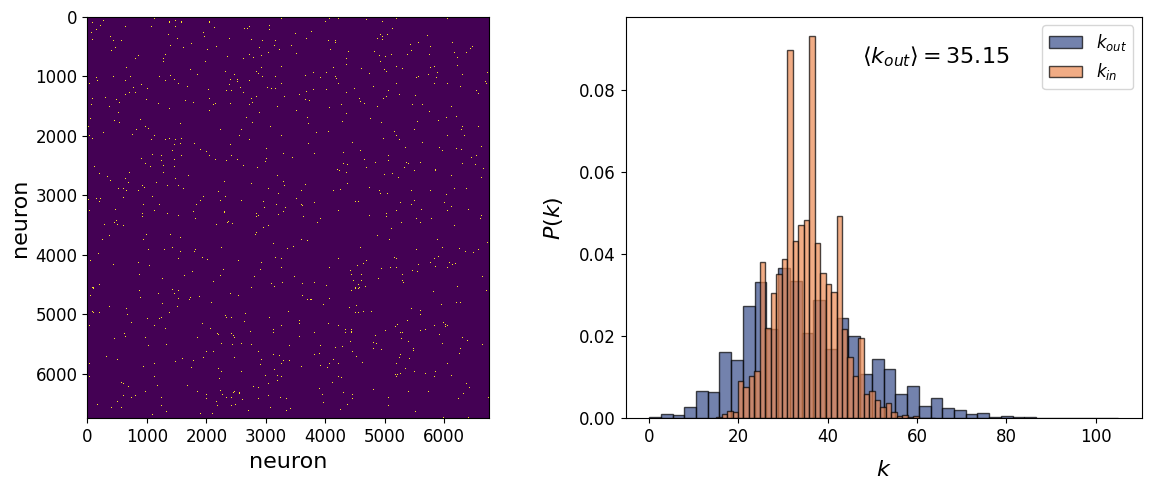

In [29]:
import numpy as np
import matplotlib.pyplot as plt

filename = output_filenames[0]

def load_A(path):
    A = np.loadtxt(path, dtype=np.uint8)
    np.fill_diagonal(A, 0)
    return A

A = load_A(filename)

sunset2 = load_cmap('Sunset2', cmap_type='continuous')


# =========================
# GRADO
# =========================
# Red dirigida: out-degree = suma por filas
k_out = A.sum(axis=1)
k_in = A.sum(axis=0)

# Para histograma discreto
k_vals = np.arange(k_out.max() + 1)
counts = np.bincount(k_out)

# =========================
# FIGURA CON DOS SUBPLOTS
# =========================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --------- MATRIZ DE ADYACENCIA ---------
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest')

ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --------- DISTRIBUCIÓN DE GRADO ---------
k_out_mean = k_out.mean()
# k_in_mean = k_in.mean()
ax = axs[1]

ax.hist(k_out, bins=40, density=True, color=sunset2(0.1), edgecolor='black', alpha=0.7, label = r'$k_{out}$')
ax.hist(k_in, bins=40, density=True, color=sunset2(0.8), edgecolor='black', alpha = 0.7, label = r'$k_{in}$')

# ax.text(0.75, 0.85, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$\n$\\langle k_{{in}} \\rangle = {k_in_mean:.2f}$", fontsize=14, ha='center', va='center', transform=ax.transAxes)

ax.text(0.6, 0.9, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$", fontsize=16, ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel(r'$k$', fontsize=16, labelpad=10)
ax.set_ylabel(r'$P(k)$', fontsize=16, labelpad=10)
ax.legend(fontsize = 12, loc = 'upper right')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import importlib
import subprocess
import numpy as np
import functions_create_networks as fcn

importlib.reload(fcn)

# =========================
# COMPILAR
# =========================
compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall",
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

# =========================
# PARÁMETROS 3D
# =========================
L = 3.0  # mm
rho = 250  # neurons/mm^3
N = int(rho * L**3)
soma_diameter = 0.015
d_mean = 0.3
d_sigma = 0.02
l_mean = 1.0
segment_length = 0.01
sigma_pol = 0.1
sigma_azi = 0.1

agg = 1
n_centers = 20
base_sigma = 0.08

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

# =========================
# BARRIDO DE PARÁMETROS
# =========================
number_of_centers = np.linspace(10, 60, 50, dtype=int)
base_sigmas = np.linspace(0.05, 0.30, 50)

Gini_values = []
filenames_Gini = []

for nc in number_of_centers:
    for s in base_sigmas:
        parameters3D["n_centers"] = nc
        parameters3D["base_sigma"] = s

        filename = fcn.run_3D_tune_positions(parameters3D, show_prints=False)
        filenames_Gini.append(filename)

        print(f"Configuration created for n_centers={nc}, base_sigma={s:.4f}", end="\r", flush=True)

print()

# =========================
# DOMINIO / GRID
# =========================
L = parameters3D["L"]
xmin = ymin = zmin = -L/2
xmax = ymax = zmax =  L/2
n_grid = 10

# =========================
# FUNCIÓN GINI 3D
# =========================
def Gini_coefficient_3D(X, Y, Z, n_grid, xmin, xmax, ymin, ymax, zmin, zmax):
    H, _ = np.histogramdd(
        sample=np.column_stack([X, Y, Z]),
        bins=(n_grid, n_grid, n_grid),
        range=((xmin, xmax), (ymin, ymax), (zmin, zmax))
    )

    bin_sum = H.sum()
    if bin_sum == 0:
        return np.nan

    H_flat = H.flatten().astype(np.float64)
    H_flat.sort()
    H_flat = H_flat[::-1]

    G = np.zeros(len(H_flat), dtype=np.float64)

    sum_gini = 0.0
    for i, h in enumerate(H_flat):
        sum_gini += h
        G[i] = sum_gini / bin_sum

    bins = np.arange(1, len(H_flat) + 1, dtype=np.float64)
    bins /= len(H_flat)

    area_between = np.trapezoid(G - bins, bins)
    Gini = 2.0 * area_between
    return Gini

# =========================
# CALCULAR ARRAY DE GINIS 3D
# =========================
for filename in filenames_Gini:
    X, Y, Z, _, _, _ = fcn.load_neuron_params_3D(filename)
    Gini = Gini_coefficient_3D(X, Y, Z, n_grid, xmin, xmax, ymin, ymax, zmin, zmax)
    Gini_values.append(Gini)

Gini_values = np.array(Gini_values)

Configuration created for n_centers=60, base_sigma=0.3000


In [ ]:
rows = []
gini3dfile = "Gini_things/Gini_3D_values.txt"

k = 0
for nc in number_of_centers:
    for s in base_sigmas:
        rows.append([nc, s, Gini_values[k]])
        k += 1

rows = np.array(rows)

np.savetxt(
    gini3dfile,
    rows,
    header="n_centers base_sigma Gini",
    fmt=["%d", "%.5f", "%.6f"]
)

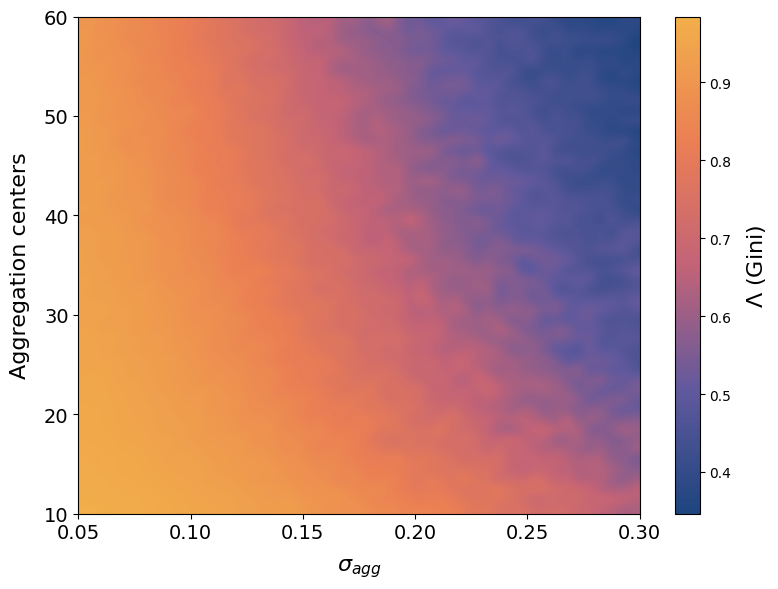

In [85]:
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

gini_data = np.loadtxt(gini3dfile, skiprows=1)

number_of_centers = np.unique(gini_data[:, 0])
base_sigmas = np.unique(gini_data[:, 1])
Gini_values = gini_data[:, 2]


Gini_map = np.array(Gini_values).reshape(len(number_of_centers), len(base_sigmas))

plt.figure(figsize=(8,6))

im = plt.imshow(
    Gini_map,
    origin='lower',
    aspect='auto',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    interpolation='bicubic'
)

plt.xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad = 10)
plt.ylabel(r'Aggregation centers', fontsize=16, labelpad  = 10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

cbar = plt.colorbar(im)
cbar.set_label(r'$\Lambda$' + ' (Gini)', fontsize=16, labelpad = 10)

plt.tight_layout()
plt.show()

# -- 3D DYNAMICS --

Configuration already exists: 3D_initial_configurations/3D_neurons_params_agg_nc10_s0.2000_L3.0_rho250_l0.70_d0.50.txt
Configuration already exists: 3D_created_networks\3D_adjacency_matrix_agg_nc10_s0.2000_L3.0_rho250_l0.70_d0.50_a0.200.txt
Shape: (6750, 6750)
k =  187.0722962962963


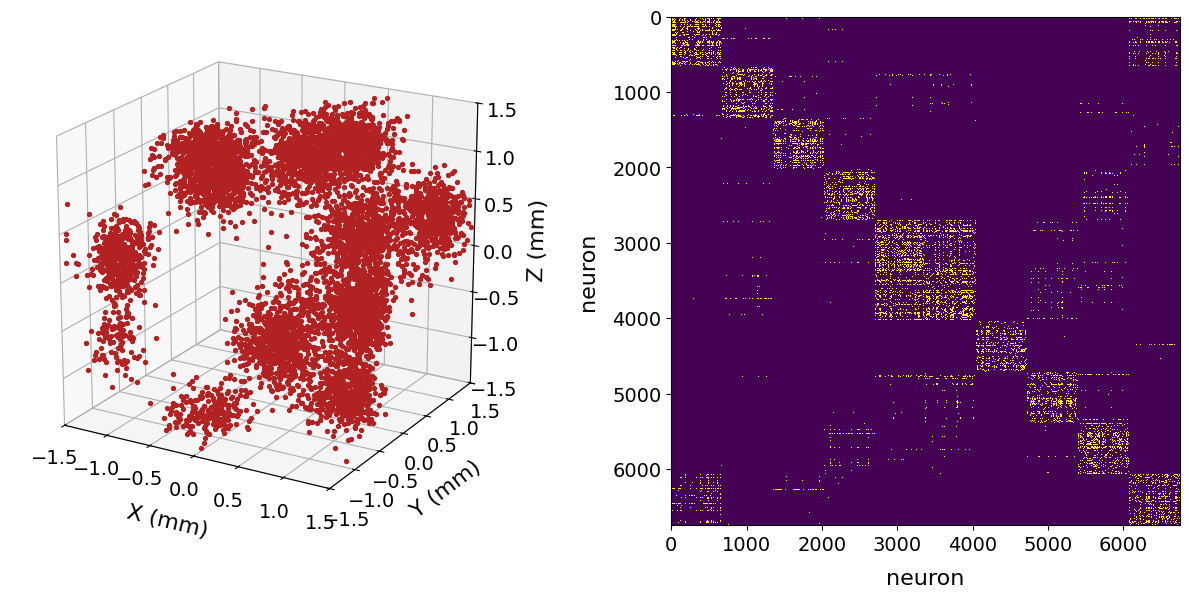

In [ ]:
import numpy as np
import subprocess
import os
import matplotlib.pyplot as plt 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# -------- PARAMETERS --------

subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.5 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.7 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.2 # Base standard deviation for aggregation centers (mm)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}


alphas = [0.2]
# alphas = np.arange(0.0, 1.01, 0.01)

filename_params = fcn.run_3D_tune_positions(parameters3D)
path = fcn.create_network3D(parameters3D, alphas)[0]

# -------- USO --------

A = fcn.load_A(path)
C, k, E = fcn.connectivity_from_A(A)

print("Shape:", A.shape)
print('k = ', k)

# Visualización
# fcn.neuron_map_adj3D(filename_params, path, parameters3D)

# -------- Pesos --------

N = A.shape[0]

Ne = int(N*0.8)
Ni = int(N*0.2)
N = Ne + Ni

SIM_TIME = 1000

# 2) Izhikevich parameters (con variabilidad)
re = np.random.rand(Ne, 1)
ri = np.random.rand(Ni, 1)

a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

MAX_EXC_WEIGTH = 4
MAX_INH_WEIGTH = 0.5

W = np.hstack([
    MAX_EXC_WEIGTH*np.random.rand(N, Ne),
    -MAX_INH_WEIGTH*np.random.rand(N, Ni)
])

S = A * W
NOISE_MAX = 3

In [38]:
v = -65*np.ones((N, 1))
u = b * v

firings_t3D = []
firings_i3D = []
    
for t in range(1, SIM_TIME+1):
    I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

    fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

    if fired.size > 0:
        firings_t3D.append(np.full(fired.shape, t, dtype=int))
        firings_i3D.append(fired.copy())

        v[fired] = c[fired]
        u[fired] = u[fired] + d[fired]

        # I = I + sum(S(:, fired), 2)
        # En numpy: sumamos columnas "fired" y nos queda vector Nx1
        I = I + np.sum(S[:, fired], axis=1, keepdims=True)

    # Integración (paso 0.5 ms x2)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    u = u + a*(b*v - u)

# Convertir lista de arrays a arrays.
#  planos
if len(firings_t3D) > 0:
    firings_t3D = np.concatenate(firings_t3D)
    firings_i3D = np.concatenate(firings_i3D) + 1  # +1 si quieres neuronas 1..N como en MATLAB
else:
    firings_t3D = np.array([], dtype=int)
    firings_i3D = np.array([], dtype=int)

print("Total spikes:", len(firings_t3D))

Total spikes: 1164090


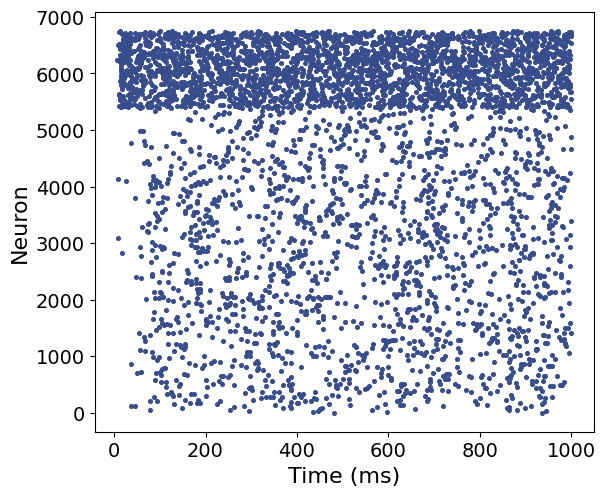

In [35]:
from pypalettes import load_cmap
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

plt.figure(figsize=(6, 5))
plt.scatter(firings_t3D, firings_i3D, s=7, color=sunset2(0.1))
plt.xlabel('Time (ms)', fontsize=16)
plt.ylabel('Neuron', fontsize=16)
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim(200, 300)
plt.show()

Número de picos detectados: 1
Alturas de los picos (%): [81.82222222]
Altura media de los picos (%): 81.82222222222222


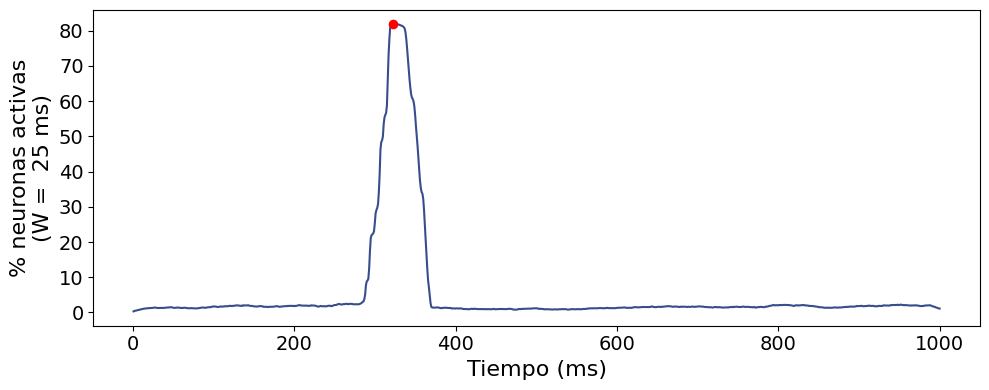

In [82]:
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks


W = 25  # ms

GNA, GNA_percent, active_neurons_count = fcn.compute_GNA_from_raster(
    firings_t=firings_t3D,
    firings_i=firings_i3D,
    N=N,
    SIM_TIME=SIM_TIME,
    W=W,
    indices_are_1_based=True   # en tu código hiciste +1 al final
)

peaks, properties = find_peaks(
    GNA_percent,
    height=10,      # altura mínima del pico en %
    distance=20    # separación mínima entre picos (ms)
)

peak_heights = properties["peak_heights"]
mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0

print("Número de picos detectados:", len(peaks))
print("Alturas de los picos (%):", peak_heights)
print("Altura media de los picos (%):", mean_peak_height)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, SIM_TIME + 1), GNA_percent, lw=1.5, color=sunset2(0.1))
plt.scatter(peaks + 1, GNA_percent[peaks], s=35, color="red", zorder=3)

plt.xlabel("Tiempo (ms)", fontsize=16)
plt.ylabel(f"% neuronas activas\n(W =  {W} ms)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.xlim(0, 2000)
plt.show()

## -- 3D GNA map --

In [ ]:
import subprocess
import numpy as np
import os

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

number_of_centers = 15
base_sigmas = np.linspace(0.05, 0.30, 50)

# Handle both a single int and an iterable of centers
n_centers_iter = np.atleast_1d(number_of_centers).astype(int)


for base_sigma in base_sigmas:
    for nc in n_centers_iter:
        parameters3D["n_centers"] = nc
        parameters3D["base_sigma"] = base_sigma

        filename = fcn.run_3D_tune_positions(parameters3D, show_prints=False)
        print(f"Configuration created for n_centers={nc}, base_sigma={base_sigma:.4f}", end="\r")

filenames_params = [
    f"3D_initial_configurations/3D_neurons_params_agg_nc{nc}_s{s:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}.txt"
    for nc in n_centers_iter
    for s in base_sigmas
]
#Check if files exist
for filename in filenames_params:
    if not os.path.isfile(filename):
        print(f"File not found: {filename}")

In [ ]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "3D_create_network.c",
    "3D_functions.c",
    "-o",
    "3D_create_network.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sgima_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (r

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sgima_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

number_of_centers = 15
parameters3D["n_centers"] = number_of_centers
base_sigmas = np.linspace(0.05, 0.30, 50)   
print('Length of base_sigmas:', len(base_sigmas))
print(base_sigmas)

alphas = [0.2]

for base_sigma in base_sigmas:
    parameters3D["base_sigma"] = base_sigma
    filename = fcn.create_network3D(parameters3D, alphas, show_prints=False)[0]
    print(filename)
    print(f"Created network for n_centers={number_of_centers}, {parameters3D['base_sigma']:.4f}", end="\r")

In [ ]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

nc = 15
parameters3D["n_centers"] = nc
base_sigmas = np.linspace(0.05, 0.30, 50)   
print('Length of base_sigmas:', len(base_sigmas))

MAX_EXC_WEIGTH = np.linspace(2, 6, len(base_sigmas))  # Puedes ajustar esto según tus necesidades
print('Length of MAX_EXC_WEIGTH:', len(MAX_EXC_WEIGTH))
MAX_INH_WEIGTH = 0.5

alpha = 0.2

output_filename = f'maps_results/3D_colormap_Gini_Exc_GNA_nc{nc}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}_a{alpha:.3f}.txt'
with open(output_filename, 'w') as f:
     f.write("Gini\tMAX_EXC_WEIGTH\tmean_peaks_height\tstd_peaks_height\n")

i = 0
for base_sigma in base_sigmas:
    parameters3D["base_sigma"] = base_sigma
    path_params = f"3D_initial_configurations/3D_neurons_params_agg_nc{parameters3D['n_centers']}_s{parameters3D['base_sigma']:.4f}_L{parameters3D['L']:.1f}_rho{parameters3D['rho']:.0f}_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}.txt"
    X, Y, _, _, _ = fcn.load_neuron_params(path_params)
    Gini = fcn.Gini_coefficient(X, Y, n_grid = 20, xmin = -parameters3D['L']/2, xmax = parameters3D['L']/2, ymin = -parameters3D['L']/2, ymax = parameters3D['L']/2)
    path_adj = f"3D_created_networks/3D_adjacency_matrix_agg_nc{parameters3D['n_centers']}_s{parameters3D['base_sigma']:.4f}_L{parameters3D['L']:.1f}_rho{parameters3D['rho']:.0f}_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}_a{alpha:.3f}.txt"
    A = fcn.load_A(path_adj)
    N = A.shape[0]

    Ne = int(N*0.8)
    Ni = int(N*0.2)
    N = Ne + Ni

    SIM_TIME = 5000

    # 2) Izhikevich parameters (con variabilidad)
    re = np.random.rand(Ne, 1)
    ri = np.random.rand(Ni, 1)

    a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
    b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
    c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
    d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

    for max_exc in MAX_EXC_WEIGTH:

        W = np.hstack([
            max_exc*np.random.rand(N, Ne),
            -MAX_INH_WEIGTH*np.random.rand(N, Ni)
        ])

        S = A * W
        NOISE_MAX = 3

        v = -65*np.ones((N, 1))
        u = b * v

        firings_t = [] # tiempos de disparo
        firings_i = [] # índices de neuronas que disparan (0..N-1)

        for t in range(1, SIM_TIME+1):
            I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

            fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

            if fired.size > 0:
                firings_t.append(np.full(fired.shape, t, dtype=int))
                firings_i.append(fired.copy())

                v[fired] = c[fired]
                u[fired] = u[fired] + d[fired]

                # I = I + sum(S(:, fired), 2)
                # En numpy: sumamos columnas "fired" y nos queda vector Nx1
                I = I + np.sum(S[:, fired], axis=1, keepdims=True)

            # Integración (paso 0.5 ms x2)
            v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
            v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
            u = u + a*(b*v - u)

        # Convertir lista de arrays a arrays.
        #  planos
        if len(firings_t) > 0:
            firings_t = np.concatenate(firings_t)
            firings_i = np.concatenate(firings_i) + 1  # +1 si quieres neuronas 1..N como en MATLAB
        else:
            firings_t = np.array([], dtype=int)
            firings_i = np.array([], dtype=int)
        
        print(f"Simulated network for base_sigma={base_sigma:.4f}, max_exc={max_exc:.2f}, Gini={Gini:.4f}, total spikes={len(firings_t)}")

        GNA, active_neurons_count = fcn.compute_GNA_from_raster(
            firings_t=firings_t,
            firings_i=firings_i,
            N=N,
            SIM_TIME=SIM_TIME,
            W=25,
            indices_are_1_based=True
        )
        peaks, properties = find_peaks(
            GNA,
            height=0.1,      # altura mínima del pico en %
            distance=20    # separación mínima entre picos (ms)
        )
        peak_heights = properties["peak_heights"]
        mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0
        print(f"Detected {len(peaks)} peaks in GNA for base_sigma={base_sigma:.4f}, max_exc={max_exc:.2f}, mean_peak_height={mean_peak_height:.4f}%")
        std_peak_height = np.std(peak_heights) if len(peak_heights) > 0 else 0.0

        with open(output_filename, 'a') as f:
            f.write(f"{Gini}\t{max_exc}\t{mean_peak_height}\t{std_peak_height}\n")
        
    i += 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el txt
df = pd.read_csv("maps_results/3D_colormap_Gini_Exc_GNA_nc15_L3.0_rho250_l0.50_d0.15_a0.200.txt", delim_whitespace=True)

# Por si acaso, revisa nombres de columnas
print(df.columns)

# Crear tabla tipo matriz
heatmap_data = df.pivot(
    index="MAX_EXC_WEIGTH",
    columns="Gini",
    values="mean_peaks_height"
)

# Dibujar mapa de calor
plt.figure(figsize=(8, 6))
im = plt.imshow(
    heatmap_data,
    origin="lower",
    aspect="auto",
    extent=[
        heatmap_data.columns.min(),
        heatmap_data.columns.max(),
        heatmap_data.index.min(),
        heatmap_data.index.max()
    ]
)

plt.xlabel("Gini")
plt.ylabel("MAX_EXC_WEIGTH")
cbar = plt.colorbar(im)
cbar.set_label("mean_peaks_height")

plt.tight_layout()
plt.show()